## Objetivo de la actividad

El objetivo de esta actividad es aplicarel algoritmo de **árboles de decisión** en un caso práctico de **control de calidad**.  
A partir de un dataset real de vinos tintos, se busca:

1. Entrenar y evaluar un modelo de **clasificación binaria** (vino de baja calidad vs vino de alta calidad).  
2. Comprender cómo los árboles generan **reglas de decisión** basadas en variables físico-químicas.  
3. Visualizar gráficamente el árbol y analizar la **importancia relativa** de cada variable en la predicción.  
4. Reflexionar sobre el uso de los árboles en problemas de **ingeniería de procesos** y **sistemas de control de calidad**.  



%%markdown
## Dataset y descripción de variables
Usaremos el dataset **Wine Quality (Red Wine)** del UCI Machine Learning Repository.  
Cada fila corresponde a una muestra de vino tinto con medidas físico-químicas.

**Variables (features):**
- `fixed acidity` (g/L)  
- `volatile acidity` (g/L)  
- `citric acid` (g/L)  
- `residual sugar` (g/L)  
- `chlorides` (g/L)  
- `free sulfur dioxide` (mg/L)  
- `total sulfur dioxide` (mg/L)  
- `density` (g/cm³)  
- `pH`  
- `sulphates` (g/L)  
- `alcohol` (% vol)

**Variable objetivo (`quality`):** puntaje de calidad sensorial del 0 al 10.  
Para el ejemplo la convertimos a clasificación binaria: **Baja calidad (≤ 5)** vs **Alta calidad (≥ 6)**.

---

## Conclusiones
- El árbol aprende **reglas simples** para separar vinos de **alta** vs **baja** calidad.  
- Las variables que suelen tener mayor peso son **alcohol**, **sulphates** y **volatile acidity**.  
- Limitar la **profundidad** y el tamaño mínimo de hojas ayuda a **evitar sobreajuste**.  
- Este enfoque es útil en **control de calidad** y **toma de decisiones automatizada** en entornos de ingeniería y procesos químicos.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
# Dataset público desde UCI (vinos tintos)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=";")

# Mostrar primeras filas
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# Crear variable binaria de calidad
df["label"] = (df["quality"] >= 6).astype(int)  # 1 = alta calidad, 0 = baja

X = df.drop(columns=["quality", "label"])
y = df["label"]

print("Dimensiones:", X.shape, y.shape)


Dimensiones: (1599, 11) (1599,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
y_pred = tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))


Accuracy: 0.7166666666666667

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.72      0.64      0.68       223
           1       0.71      0.79      0.75       257

    accuracy                           0.72       480
   macro avg       0.72      0.71      0.71       480
weighted avg       0.72      0.72      0.71       480



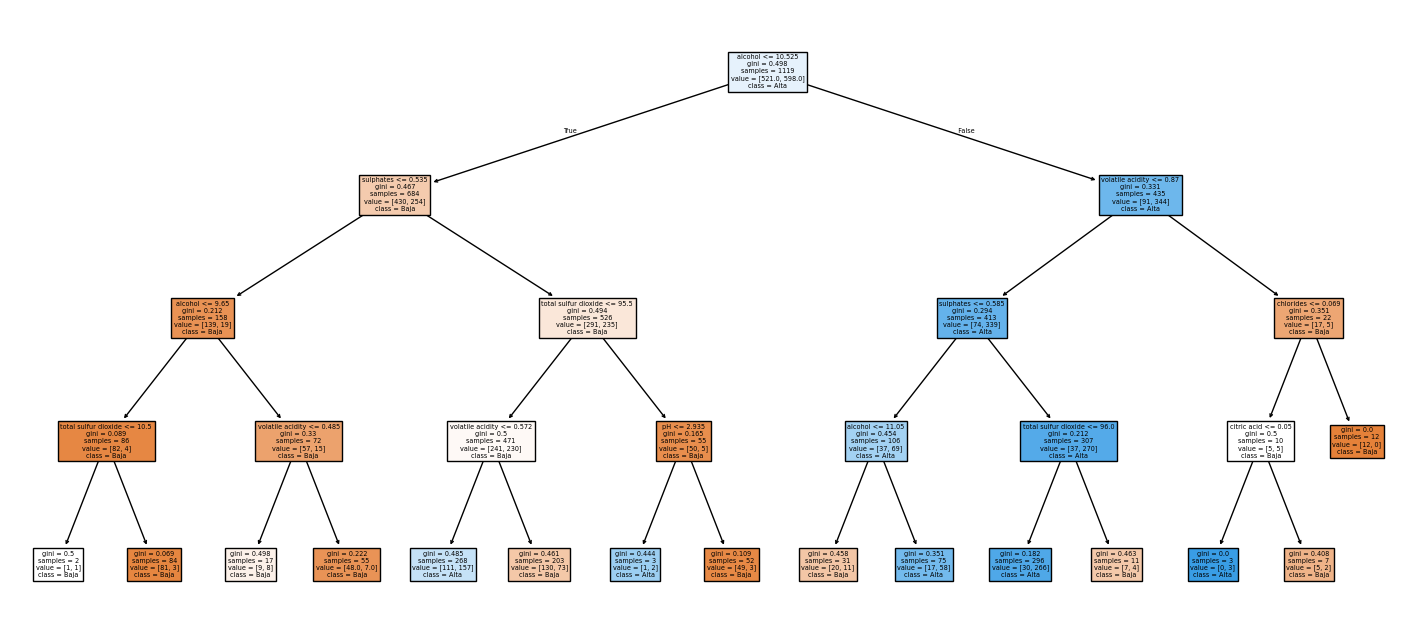

In [ ]:
plt.figure(figsize=(18,8))
plot_tree(tree, feature_names=X.columns, class_names=["Baja", "Alta"], filled=True)
plt.show()


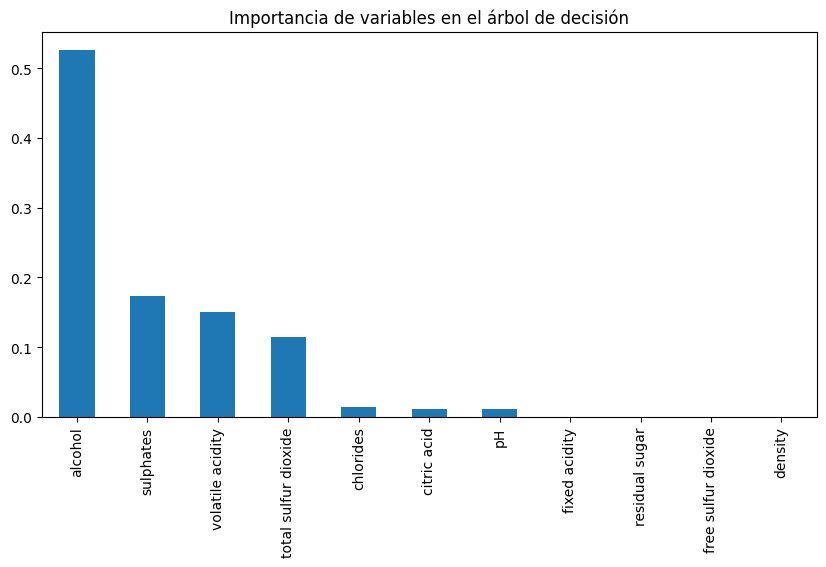

In [ ]:
importances = pd.Series(tree.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind="bar", figsize=(10,5))
plt.title("Importancia de variables en el árbol de decisión")
plt.show()
